# UCI Bank Marketing - Phase 1: Forensic Data Audit & EDA

### Business Context:
A retail bank conducts outbound telemarketing campaigns to sell term deposits. Due to operational capacity constraints, the sales team can call only **5,000 customers** from the eligible prospect pool.

### Core Strategic Objectives:
1. **Supervised Optimization**: Identify and rank-order leads by conversion probability to maximize subscriptions within the 5,000-call quota.
2. **Unsupervised Discovery**: Uncover actionable customer segments to understand who the campaign reaches and tailor messaging.

### Phase 1 Audit Mandate:
Perform a comprehensive data audit and exploratory analysis **before building any models**. Specifically investigate:
- **Baseline economics & target prevalence**
- **Target leakage** in `duration`
- **Campaign fatigue & diminishing returns** in `campaign`
- **Prior contact dynamics** in `pdays`, `previous`, and `poutcome`
- **Implicit missingness** ('unknown' / NaN)
- **Repeated demographic profiles**


In [1]:
import sys
from pathlib import Path

# Ensure project root is in path
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

from src.data.load_data import load_bank_marketing_data
print("Libraries loaded successfully!")


Libraries loaded successfully!


## 1. Data Ingestion & Schema Verification


In [2]:
# Load cached dataset
X, y = load_bank_marketing_data()
df = X.copy()
df['target'] = y

print(f"Total Records: {len(df):,}")
print(f"Total Features: {X.shape[1]}")
print("\nFeatures Data Types:")
print(df.dtypes)
df.head(5)


[2026-09-10 14:12:53] [INFO] src.data.load_data: Loading cached dataset from C:\Users\usasl\PycharmProjects\uci_banking_ML_project\data\raw\bank_features.csv and C:\Users\usasl\PycharmProjects\uci_banking_ML_project\data\raw\bank_targets.csv


Total Records: 45,211
Total Features: 16

Features Data Types:
age            int64
job              str
marital          str
education        str
default          str
balance        int64
housing          str
loan             str
contact          str
day_of_week    int64
month            str
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome         str
target           str
dtype: object


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## 2. Target Prevalence & The 5,000-Call Quota Baseline

### Business Benchmark:
With an eligible population of 45,211 contacts and a positive prevalence of **11.70%**, a random outreach of **5,000 leads** yields an expected **585 conversions**.

$$\mathbb{E}[\text{Conversions}] = 5,000 \times 0.1170 \approx 585 \text{ subscriptions}$$

All subsequent models must be measured against this baseline (Lift @ 5,000 calls).


Target Distribution:
  'no': 39,922 (88.30%)
  'yes': 5,289 (11.70%)

Expected conversions from 5,000 random calls: 585


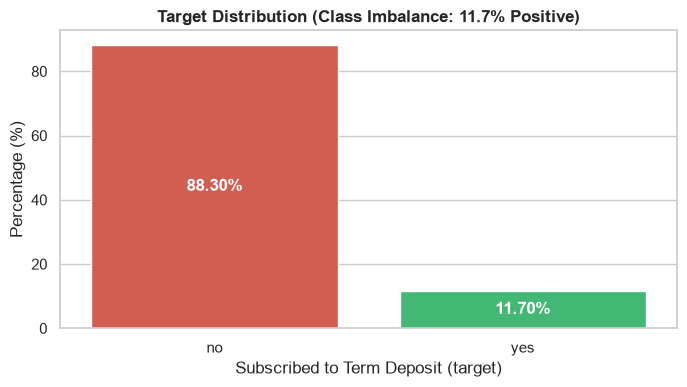

In [3]:
# Compute target prevalence
target_counts = df['target'].value_counts()
target_props = df['target'].value_counts(normalize=True)

print("Target Distribution:")
for k in target_counts.index:
    print(f"  '{k}': {target_counts[k]:,} ({target_props[k]*100:.2f}%)")

cap = 5000
expected_baseline = int(round(cap * target_props['yes']))
print(f"\nExpected conversions from 5,000 random calls: {expected_baseline:,}")

# Plot target distribution
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=target_props.index, y=target_props.values * 100, hue=target_props.index, palette=["#e74c3c", "#2ecc71"], legend=False, ax=ax)
ax.set_title("Target Distribution (Class Imbalance: 11.7% Positive)", fontsize=12, fontweight="bold")
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Subscribed to Term Deposit (target)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## 3. Forensic Leakage Investigation: `duration`

> [!WARNING]
> **UCI Warning**: Call duration is strictly known **only after** the phone call has completed. A customer who says 'no' hangs up in under 60 seconds. A customer who subscribes stays on the line for minutes to complete disclosures. Including `duration` creates massive target leakage that renders pre-call scoring useless in production.


Univariate ROC-AUC on 'duration' ALONE: 0.8076

Duration summary statistics (seconds) by target:
              mean         std  min    50%    75%     max
target                                                   
no      221.182806  207.383237  0.0  164.0  279.0  4918.0
yes     537.294574  392.525262  8.0  426.0  725.0  3881.0

Calls with duration = 0s: 3 (Conversion rate: 0.0%)


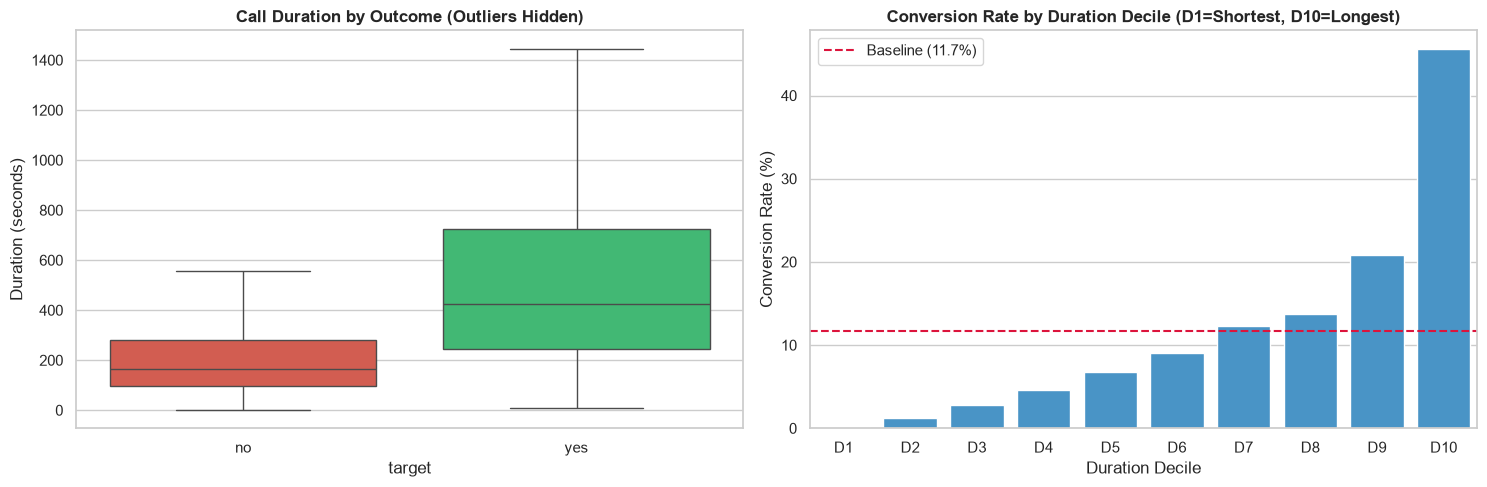

In [4]:
# 1. ROC-AUC of duration alone
y_binary = (df['target'] == 'yes').astype(int)
duration_auc = roc_auc_score(y_binary, df['duration'])
print(f"Univariate ROC-AUC on 'duration' ALONE: {duration_auc:.4f}")

# 2. Duration summary statistics by target
print("\nDuration summary statistics (seconds) by target:")
print(df.groupby('target')['duration'].describe()[['mean', 'std', 'min', '50%', '75%', 'max']])

# 3. Check duration = 0
zero_dur = df[df['duration'] == 0]
print(f"\nCalls with duration = 0s: {len(zero_dur)} (Conversion rate: {(zero_dur['target'] == 'yes').mean()*100:.1f}%)")

# 4. Visualization: Boxplot and Decile Conversion Rate
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot
sns.boxplot(data=df, x='target', y='duration', hue='target', showfliers=False, palette=["#e74c3c", "#2ecc71"], legend=False, ax=axes[0])
axes[0].set_title("Call Duration by Outcome (Outliers Hidden)", fontweight="bold")
axes[0].set_ylabel("Duration (seconds)")

# Deciles
df_temp = df[['duration', 'target']].copy()
df_temp['duration_decile'] = pd.qcut(df_temp['duration'], q=10)
decile_conv = df_temp.groupby('duration_decile', observed=False)['target'].agg(lambda s: (s == 'yes').mean() * 100).reset_index()
decile_conv['decile'] = [f"D{i+1}" for i in range(len(decile_conv))]

sns.barplot(data=decile_conv, x='decile', y='target', color='#3498db', ax=axes[1])
axes[1].axhline(y=11.70, color='crimson', linestyle='--', label='Baseline (11.7%)')
axes[1].set_title("Conversion Rate by Duration Decile (D1=Shortest, D10=Longest)", fontweight="bold")
axes[1].set_xlabel("Duration Decile")
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Campaign Outreach Dynamics & Diminishing Returns (`campaign`)

Investigating the number of contacts made during the current campaign reveals severe diminishing returns beyond 3-4 contacts.


campaign_tier  call_volume  conversions  conversion_rate  pct_of_all_calls
    1 contact        17544         2561        14.597583         38.804716
   2 contacts        12505         1401        11.203519         27.659198
   3 contacts         5521          618        11.193624         12.211630
 4-5 contacts         5286          456         8.626561         11.691845
6-10 contacts         3159          206         6.521051          6.987238
 >10 contacts         1196           47         3.929766          2.645374


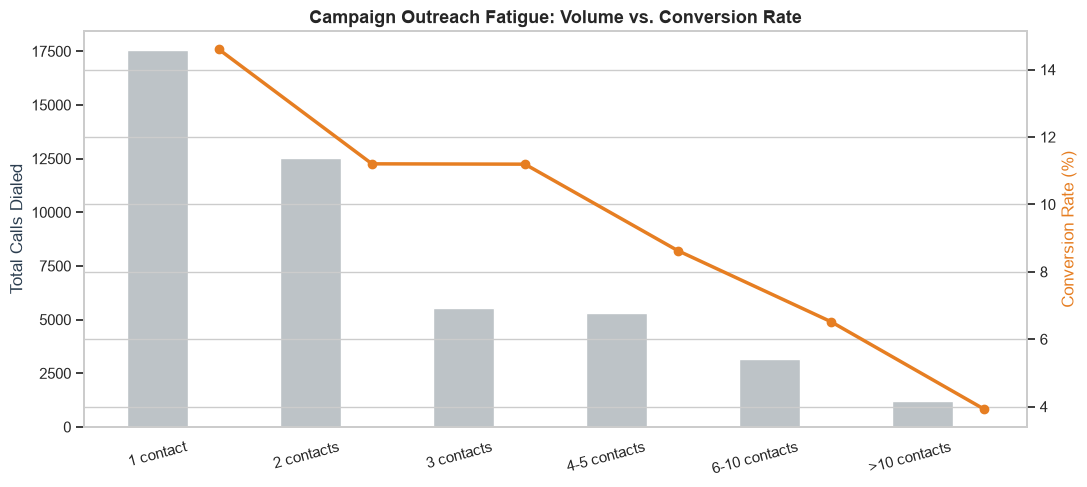

In [5]:
bins = [0, 1, 2, 3, 5, 10, 100]
labels = ["1 contact", "2 contacts", "3 contacts", "4-5 contacts", "6-10 contacts", ">10 contacts"]
df_camp = df[['campaign', 'target']].copy()
df_camp['campaign_tier'] = pd.cut(df_camp['campaign'], bins=bins, labels=labels)

camp_summary = df_camp.groupby('campaign_tier', observed=False)['target'].agg(
    call_volume='count',
    conversions=lambda s: (s == 'yes').sum(),
    conversion_rate=lambda s: (s == 'yes').mean() * 100
).reset_index()
camp_summary['pct_of_all_calls'] = camp_summary['call_volume'] / len(df) * 100

print(camp_summary.to_string(index=False))

# Visualization: Call Volume vs Conversion Rate
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = np.arange(len(camp_summary))
width = 0.4
ax1.bar(x - width/2, camp_summary['call_volume'], width=width, color='#bdc3c7', label='Total Calls Dialed')
ax2.plot(x + width/2, camp_summary['conversion_rate'], color='#e67e22', marker='o', linewidth=2.5, label='Conversion Rate (%)')

ax1.set_xticks(x)
ax1.set_xticklabels(camp_summary['campaign_tier'], rotation=15, ha='right')
ax1.set_ylabel('Total Calls Dialed', color='#2c3e50')
ax2.set_ylabel('Conversion Rate (%)', color='#e67e22')
ax1.set_title("Campaign Outreach Fatigue: Volume vs. Conversion Rate", fontsize=13, fontweight='bold')
ax1.grid(False)

plt.tight_layout()
plt.show()


## 5. Prior Campaign History: `pdays`, `previous`, and `poutcome`

- `pdays = -1` indicates clients never contacted in any prior campaign (**81.74%** of records).
- What happens when a prospect was previously contacted? How does prior outcome (`poutcome`) predict current conversion?


--- Prior Contact Cohort Comparison ---


             contact_history  volume  conversions  conversion_rate
     Never Contacted (81.7%)   36954         3384         9.157331
Previously Contacted (18.3%)    8257         1905        23.071333

--- Prior Outcome (poutcome) Breakdown ---
prior_outcome  volume  conversions  conversion_rate
      failure    4901          618        12.609671
        other    1840          307        16.684783
      success    1511          978        64.725347
      unknown   36959         3386         9.161503


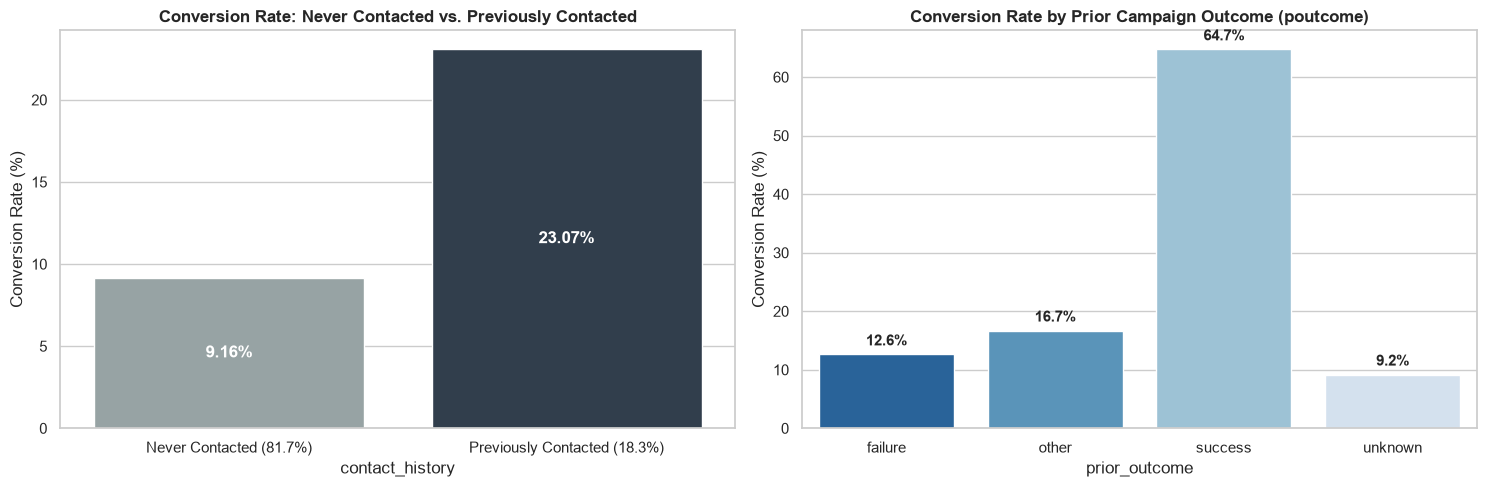

In [6]:
df_prior = df.copy()
df_prior['contact_history'] = np.where(df_prior['pdays'] == -1, 'Never Contacted (81.7%)', 'Previously Contacted (18.3%)')

pdays_stats = df_prior.groupby('contact_history')['target'].agg(
    volume='count',
    conversions=lambda s: (s == 'yes').sum(),
    conversion_rate=lambda s: (s == 'yes').mean() * 100
).reset_index()
print("--- Prior Contact Cohort Comparison ---")
print(pdays_stats.to_string(index=False))

pout_stats = df_prior.groupby(df_prior['poutcome'].fillna('unknown'))['target'].agg(
    volume='count',
    conversions=lambda s: (s == 'yes').sum(),
    conversion_rate=lambda s: (s == 'yes').mean() * 100
).reset_index().rename(columns={'poutcome': 'prior_outcome'})
print("\n--- Prior Outcome (poutcome) Breakdown ---")
print(pout_stats.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=pdays_stats, x='contact_history', y='conversion_rate', hue='contact_history', palette=['#95a5a6', '#2c3e50'], legend=False, ax=axes[0])
axes[0].set_title("Conversion Rate: Never Contacted vs. Previously Contacted", fontweight='bold')
axes[0].set_ylabel("Conversion Rate (%)")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=12)

sns.barplot(data=pout_stats, x='prior_outcome', y='conversion_rate', hue='prior_outcome', palette='Blues_r', legend=False, ax=axes[1])
axes[1].set_title("Conversion Rate by Prior Campaign Outcome (poutcome)", fontweight='bold')
axes[1].set_ylabel("Conversion Rate (%)")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 6. Campaign Timing & Seasonality: The 'May Trap'

Comparing total outreach volume to conversion efficiency across calendar months.


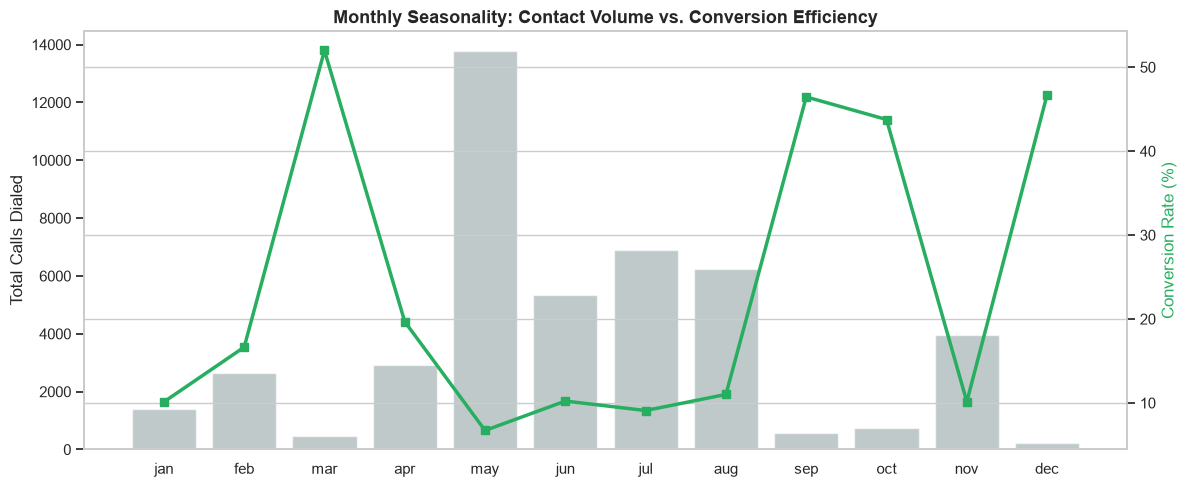

In [7]:
month_order = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
month_df = df.groupby('month')['target'].agg(
    calls_dialed='count',
    conversions=lambda s: (s == 'yes').sum(),
    conversion_rate=lambda s: (s == 'yes').mean() * 100
).reindex(month_order).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(month_df['month'], month_df['calls_dialed'], color='#95a5a6', alpha=0.6, label='Calls Dialed')
ax2.plot(month_df['month'], month_df['conversion_rate'], color='#27ae60', marker='s', linewidth=2.5, label='Conversion Rate (%)')

ax1.set_ylabel('Total Calls Dialed')
ax2.set_ylabel('Conversion Rate (%)', color='#27ae60')
ax1.set_title("Monthly Seasonality: Contact Volume vs. Conversion Efficiency", fontsize=13, fontweight='bold')
ax1.grid(False)

plt.tight_layout()
plt.show()


## 7. Data Quality, Missingness & Demographic Duplication

- True missing values (NaN) vs encoded strings ('unknown').
- Assessing potential repeated client records across campaigns.


In [8]:
# Missing values
print("Missing (NaN) Counts:")
nan_counts = df.isna().sum()[lambda x: x > 0]
print(nan_counts)

# Demographic duplicates
demo_cols = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
n_duplicates = df.duplicated(subset=demo_cols).sum()
print(f"\nDuplicate demographic profiles: {n_duplicates:,} out of {len(df):,} ({n_duplicates/len(df)*100:.2f}%)")
print("Unit of analysis: Contact-level interactions rather than strictly unique customer IDs.")


Missing (NaN) Counts:
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64

Duplicate demographic profiles: 4,163 out of 45,211 (9.21%)
Unit of analysis: Contact-level interactions rather than strictly unique customer IDs.


## 8. Summary of Phase 1 Findings & Phase 2 Architecture

### Key Audit Conclusions:
1. **Target Baseline**: Fixed capacity of 5,000 calls produces **585 conversions** under random selection (11.70% base rate).
2. **Leakage Elimination**: `duration` (ROC-AUC = 0.8076) is post-call information and must be excluded from all pre-call models.
3. **Primary Predictive Drivers**:
   - `poutcome == 'success'` converts at **64.73%** (5.5x higher than average).
   - Past contact (`pdays != -1`) converts at **23.07%** (2.5x higher than first-time leads).
   - Severe outreach fatigue beyond 3-4 contacts per campaign.
4. **Data Preprocessing Directives for Phase 2**:
   - Drop `duration`.
   - Engineer `was_previously_contacted` boolean flag and binned recency.
   - Treat `'unknown'` / NaN as an explicit categorical state for `poutcome` and `contact`.
   - Model evaluation focused on **Precision@5,000** and **Lift curves**.
